# PCA y clasificación de subtipos de cáncer de mama.
Clasificar subtipos de cáncer de mama

1. PCA: Justificar la selección de varianza explicada, interpretar los loadings de los primeros componentes, visualizar los primeros componentes coloreando por clase.
2. LR: Explorar algoritmos revisados en clases (Grid search). Obtener e interpretar métricas de clasificación vistas en clases.

In [68]:
# Librerias
from sklearn.decomposition import PCA #para el PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler #para scaler

In [69]:
# Cargar los datos
data = pd.read_csv("Breast_GSE45827.csv")

In [70]:
# Separar los datos en X e Y
X = data.drop(columns=['samples', 'type'])
Y = data['type']

In [71]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=1, stratify=Y)

In [72]:
# Escalar los datos
scaler = StandardScaler()
X_train_scalar = scaler.fit_transform(X_train)
X_test_scalar = scaler.transform(X_test)

## PCA

In [73]:
# Hacer el PCA
pca = PCA()
pca.fit(X_train_scalar)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

Para tener el 90% de la varianza se necesita: 85.0 componentes


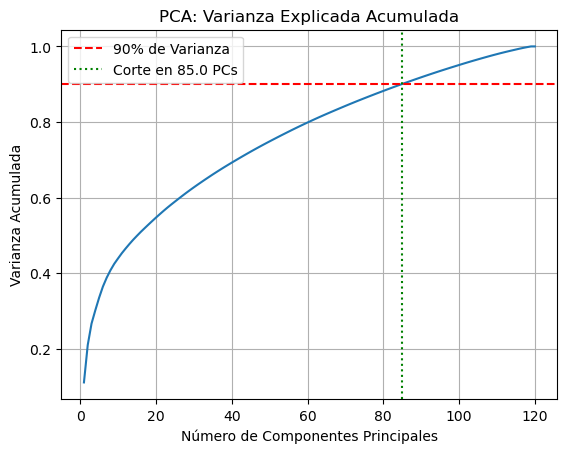

In [74]:
# Caclular la varianza
exp_var = pd.DataFrame(pca.explained_variance_ratio_, columns=["exp_var"])
exp_var["pc"] = exp_var.index + 1 # Le damos un número a cada componente (PC1, PC2, etc.)
exp_var["cumsum"] = exp_var["exp_var"].cumsum()

componentes_90 = exp_var[exp_var["cumsum"] >= 0.9].iloc[0].pc
print(f"Para tener el 90% de la varianza se necesita: {componentes_90} componentes")

sns.lineplot(data=exp_var, x="pc", y="cumsum")
plt.axhline(0.9, color='red', linestyle='--', label='90% de Varianza')
plt.axvline(componentes_90, color='green', linestyle=':', label=f'Corte en {componentes_90} PCs')
plt.title('PCA: Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.legend()
plt.grid(True)
plt.show()

In [75]:
# PCA final, con los 85 componentes 
pca_final = PCA(n_components=int(componentes_90))

X_train_pca = pca_final.fit_transform(X_train_scalar) 
X_test_pca = pca_final.transform(X_test_scalar)

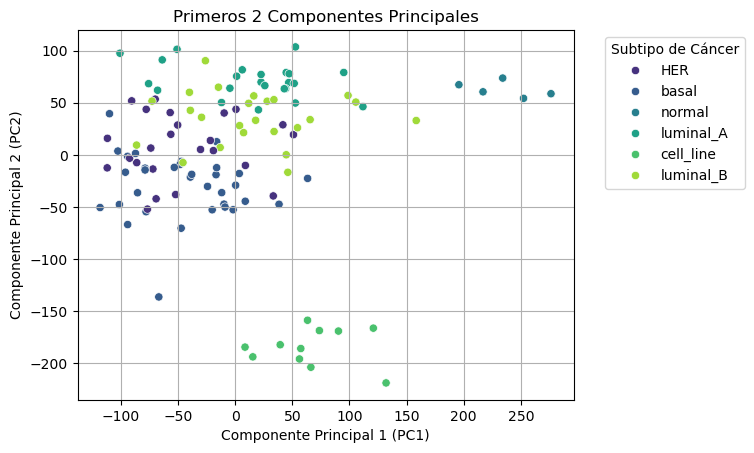

In [76]:
# Graficar los primeros componentes
X_train_pca_df = pd.DataFrame(X_train_pca)

sns.scatterplot(
    data=X_train_pca_df, x=0, y=1, hue=y_train.values, palette="viridis"
)

plt.title('Primeros 2 Componentes Principales')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(title='Subtipo de Cáncer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

In [77]:
# Ver los principales loadings
loadings = pd.DataFrame(pca_final.components_, columns=X.columns)

loadings_pc1 = loadings.iloc[0].sort_values(ascending=False)

print("--- TOP 5 GENES QUE MÁS APORTAN POSITIVAMENTE A PC1 ---")
print(loadings_pc1.head(5))

print("\n--- TOP 5 GENES QUE MÁS APORTAN NEGATIVAMENTE A PC1 ---")
print(loadings_pc1.tail(5))

--- TOP 5 GENES QUE MÁS APORTAN POSITIVAMENTE A PC1 ---
1560451_at    0.010889
206849_at     0.010753
216102_at     0.010741
1561413_at    0.010682
241945_at     0.010680
Name: 0, dtype: float64

--- TOP 5 GENES QUE MÁS APORTAN NEGATIVAMENTE A PC1 ---
204313_s_at   -0.009537
237062_at     -0.009548
1569142_at    -0.009553
210057_at     -0.009741
233303_at     -0.009775
Name: 0, dtype: float64


## LR con Grid

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')   #esto porque sino sale una advertencia giganteeeeeeee

lr = LogisticRegression(max_iter=5000, solver='saga', random_state=42)

parametros = {
    'C': [0.1, 1.0, 10.0],
    'penalty': ['l1', 'l2']
}

grid = GridSearchCV(estimator=lr, param_grid=parametros, cv=3, scoring='accuracy', n_jobs=-1)

grid.fit(X_train_pca, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejores hiperparámetros: {'C': 0.1, 'penalty': 'l2'}


### Metrica de clasificacion

In [79]:
mejor_lr = grid.best_estimator_

y_pred = mejor_lr.predict(X_test_pca)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.75      1.00      0.86         6
   luminal_B       1.00      0.83      0.91         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.94        31
   macro avg       0.96      0.89      0.91        31
weighted avg       0.95      0.94      0.93        31

